In [1]:
from pathlib import Path

print("Notebook working folder:", Path.cwd())

print("\nFiles in this folder:")
for file in Path.cwd().iterdir():
    print(file.name)

Notebook working folder: C:\Users\abc\freight-assessment

Files in this folder:
.ipynb_checkpoints
assessment.ipynb
data
README.md
score.py


In [2]:
from pathlib import Path

required_files = [
    "score.py",
    "data/train-test.csv",
    "data/validation.csv",
    "data/validation-predictions-template.csv",
    "data/december-chart-inputs.csv",
    "data/freight-rate-ml-assessment.pdf",
]

for name in required_files:
    status = "FOUND" if Path(name).is_file() else "MISSING"
    print(f"{status}: {name}")

FOUND: score.py
FOUND: data/train-test.csv
FOUND: data/validation.csv
FOUND: data/validation-predictions-template.csv
FOUND: data/december-chart-inputs.csv
FOUND: data/freight-rate-ml-assessment.pdf


In [3]:
%pip install pandas numpy scikit-learn matplotlib joblib

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB 653.6 kB/s eta 0:00:13
   ---------------------------------------- 0.0/8.3 MB 653.6 kB/s eta 0:00:13
   ---------------------------------------- 0.1/8.3 MB 508.4 kB/s eta 0:00:17
    --------------------------------------- 0.1/8.3 MB 554.9 kB/s eta 0:00:15
    --------------------------------------- 0.1/8.3 MB 655.8 kB/s eta 0:00:13
    --------------------------------------- 0.2/8.3 MB 583.1 kB/s eta 0:00:14
   - -------------------------------------- 0.2/8.3 MB 718.0 kB/s eta 0:00:12
   - -------------------------------------- 0.3/8.3 MB 912.8 kB/s eta 0:00:09
   - -------------------------------------- 0.4/8.3 MB 897.8 kB/s eta 0:00:09
   -- ------------------------------------- 0.5/8.3 MB 1.0 MB/s eta 0:00:08
   -- 

In [1]:
from pathlib import Path
import pandas as pd

DATA = Path("data")
OUTPUT = Path("outputs")
OUTPUT.mkdir(exist_ok=True)

train = pd.read_csv(DATA / "train-test.csv")
validation = pd.read_csv(DATA / "validation.csv")
template = pd.read_csv(DATA / "validation-predictions-template.csv")
december = pd.read_csv(DATA / "december-chart-inputs.csv")

print("Training:", train.shape)
print("Validation:", validation.shape)
print("Template:", template.shape)
print("December:", december.shape)

train.head()

Training: (48000, 14)
Validation: (12000, 13)
Template: (12000, 2)
December: (31, 7)


,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28


In [2]:
print("Dataset sizes:")
print("Training:", train.shape)
print("Validation:", validation.shape)
print("Template:", template.shape)
print("December:", december.shape)

print("\nMissing values:")
display(pd.DataFrame({
    "Training": train.isna().sum(),
    "Validation": validation.isna().sum()
}).fillna(0).astype(int))

print("\nDuplicate rows:", train.duplicated().sum())
print("Duplicate training IDs:", train["load_id"].duplicated().sum())

print("\nTraining weights at or below zero:",
      (train["weight"] <= 0).sum())

print("Validation weights at or below zero:",
      (validation["weight"] <= 0).sum())

print("\nTraining price summary:")
display(train["posted_rate"].describe())

Dataset sizes:
Training: (48000, 14)
Validation: (12000, 13)
Template: (12000, 2)
December: (31, 7)

Missing values:


,Training,Validation
date,0,0
delivery,0,0
delivery_lat,0,0
delivery_lon,0,0
distance,0,0
equipment,0,0
load_id,0,0
market_index,374,249
pickup,0,0
pickup_lat,0,0



Duplicate rows: 0
Duplicate training IDs: 0

Training weights at or below zero: 292
Validation weights at or below zero: 145

Training price summary:


count    48000.000000
mean      2373.980682
std       1486.493245
min         57.220000
25%       1251.555000
50%       2030.760000
75%       3330.750000
max      25533.000000
Name: posted_rate, dtype: float64

In [3]:
for frame in [train, validation, december]:
    frame["date"] = pd.to_datetime(
        frame["date"],
        errors="raise"
    )

print("Training dates:",
      train["date"].min().date(),
      "to",
      train["date"].max().date())

print("Validation dates:",
      validation["date"].min().date(),
      "to",
      validation["date"].max().date())

Training dates: 2025-01-01 to 2025-10-31
Validation dates: 2025-11-01 to 2025-12-31


In [4]:
initial_train = train[
    train["date"] < "2025-07-01"
].copy()

selection_set = train[
    (train["date"] >= "2025-07-01") &
    (train["date"] < "2025-09-01")
].copy()

final_test = train[
    train["date"] >= "2025-09-01"
].copy()

print("Initial training:", len(initial_train))
print("Model selection:", len(selection_set))
print("Final internal test:", len(final_test))

assert (
    len(initial_train) + len(selection_set) + len(final_test)
    == len(train)
)

Initial training: 28806
Model selection: 9671
Final internal test: 9523


In [5]:
import numpy as np

CATEGORICAL = ["pickup", "delivery", "equipment"]

def make_features(frame, use_signals=False):
    columns = CATEGORICAL + [
        "distance", "weight",
        "pickup_lat", "pickup_lon",
        "delivery_lat", "delivery_lon"
    ]

    features = frame[columns].copy()

    # Treat zero and negative weights as missing.
    features["weight"] = features["weight"].where(
        features["weight"] > 0
    )

    dates = pd.to_datetime(frame["date"])

    features["weekday"] = dates.dt.dayofweek
    features["weekend"] = (
        dates.dt.dayofweek >= 5
    ).astype(int)

    # Represent the position within the year.
    features["annual_sin"] = np.sin(
        2 * np.pi * (dates.dt.dayofyear - 1) / 365.25
    )
    features["annual_cos"] = np.cos(
        2 * np.pi * (dates.dt.dayofyear - 1) / 365.25
    )

    features["lat_delta"] = (
        features["delivery_lat"] - features["pickup_lat"]
    )
    features["lon_delta"] = (
        features["delivery_lon"] - features["pickup_lon"]
    )

    features["log_distance"] = np.log(features["distance"])
    features["inverse_distance"] = 1 / features["distance"]

    if use_signals:
        features["market_index"] = frame["market_index"]
        features["quote_signal"] = frame["quote_signal"]

    return features

In [6]:
core_features = make_features(initial_train)
full_features = make_features(initial_train, use_signals=True)

print("Core features:", core_features.shape)
print("Full features:", full_features.shape)

display(full_features.head())

Core features: (28806, 17)
Full features: (28806, 19)


,pickup,delivery,equipment,distance,weight,pickup_lat,pickup_lon,delivery_lat,delivery_lon,weekday,weekend,annual_sin,annual_cos,lat_delta,lon_delta,log_distance,inverse_distance,market_index,quote_signal
0,Richmond,Baltimore,Dry Van,274.3,30658.0,38.09122,-76.78906,38.16908,-72.74564,2,0,0.0,1.0,0.07786,4.04342,5.614222,0.003646,0.95684,2.39595
1,Richmond,Philadelphia,Reefer,280.5,17555.0,38.09122,-76.78906,39.22317,-72.96710,2,0,0.0,1.0,1.13195,3.82196,5.636574,0.003565,0.97623,2.43355
2,Philadelphia,Green Bay,Dry Van,967.8,31721.0,39.22317,-72.96710,44.30296,-87.52871,2,0,0.0,1.0,5.07979,-14.56161,6.875025,0.001033,1.00971,1.84491
3,Hartford,Atlanta,Dry Van,965.4,32333.0,39.55328,-72.18051,34.84933,-86.28940,2,0,0.0,1.0,-4.70395,-14.10889,6.872543,0.001036,0.94518,1.87712
4,Dallas,Nashville,Reefer,541.9,35183.0,31.83025,-94.38343,35.29479,-88.08915,2,0,0.0,1.0,3.46454,6.29428,6.295081,0.001845,0.98480,2.56300


In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor

def build_model(kind, feature_frame):
    numeric_columns = [
        column for column in feature_frame.columns
        if column not in CATEGORICAL
    ]

    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(
            strategy="median",
            add_indicator=True
        )),
        ("scaler", StandardScaler())
    ])

    # Support newer and older scikit-learn versions.
    try:
        encoder = OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    except TypeError:
        encoder = OneHotEncoder(
            handle_unknown="ignore",
            sparse=False
        )

    preprocessing = ColumnTransformer([
        ("numeric", numeric_pipeline, numeric_columns),
        ("categorical", encoder, CATEGORICAL)
    ])

    if kind == "ridge":
        estimator = Ridge(alpha=50)

    elif kind == "boosting":
        estimator = HistGradientBoostingRegressor(
            loss="absolute_error",
            max_iter=180,
            learning_rate=0.07,
            max_leaf_nodes=23,
            min_samples_leaf=45,
            l2_regularization=5,
            early_stopping=False,
            random_state=42
        )

    else:
        raise ValueError("Choose 'ridge' or 'boosting'.")

    return Pipeline([
        ("preprocessing", preprocessing),
        ("model", estimator)
    ])

In [8]:
ridge_pipeline = build_model("ridge", full_features)
boosting_pipeline = build_model("boosting", full_features)

print("Ridge pipeline created.")
print("Boosting pipeline created.")

Ridge pipeline created.
Boosting pipeline created.


In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate(actual, predicted):
    actual = np.asarray(actual)
    predicted = np.asarray(predicted)

    return {
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": np.sqrt(mean_squared_error(actual, predicted)),
        "Median error": np.median(np.abs(actual - predicted)),
        "MAPE (%)": np.mean(
            np.abs(actual - predicted) / actual
        ) * 100
    }


def fit_model(training_frame, kind, use_signals):
    features = make_features(training_frame, use_signals)

    # Predict dollars per mile.
    target = (
        training_frame["posted_rate"] /
        training_frame["distance"]
    )

    model = build_model(kind, features)

    if kind == "boosting":
        model.fit(
            features,
            target,
            model__sample_weight=training_frame["distance"].to_numpy()
        )
    else:
        model.fit(features, target)

    return model


def predict_rates(model, frame, use_signals):
    features = make_features(frame, use_signals)

    predicted_per_mile = model.predict(features)

    # Convert dollars per mile into the total load price.
    predicted_total = (
        predicted_per_mile * frame["distance"].to_numpy()
    )

    return np.maximum(predicted_total, 1.0)

In [10]:
# Simple baseline: one typical training price per mile.
baseline_per_mile = np.median(
    initial_train["posted_rate"] /
    initial_train["distance"]
)

baseline_predictions = (
    selection_set["distance"].to_numpy() * baseline_per_mile
)

results = {
    "baseline": evaluate(
        selection_set["posted_rate"],
        baseline_predictions
    )
}

settings = {
    "ridge_core": ("ridge", False),
    "ridge_full": ("ridge", True),
    "boosting_core": ("boosting", False),
    "boosting_full": ("boosting", True)
}

for name, (kind, use_signals) in settings.items():
    print(f"Training {name}...", flush=True)

    model = fit_model(
        initial_train, kind, use_signals
    )

    predictions = predict_rates(
        model, selection_set, use_signals
    )

    results[name] = evaluate(
        selection_set["posted_rate"],
        predictions
    )

    print(f"Finished — MAE: ${results[name]['MAE']:.2f}")

comparison = pd.DataFrame(results).T.sort_values("MAE")

display(comparison.round(2))

Training ridge_core...
Finished — MAE: $188.03
Training ridge_full...
Finished — MAE: $148.09
Training boosting_core...
Finished — MAE: $152.99
Training boosting_full...
Finished — MAE: $148.39


,MAE,RMSE,Median error,MAPE (%)
ridge_full,148.09,625.60,72.24,6.36
boosting_full,148.39,630.64,57.08,6.54
boosting_core,152.99,626.88,74.22,6.43
ridge_core,188.03,634.13,107.89,8.17
baseline,249.01,674.72,135.53,11.16


In [11]:
best_name = comparison.index[0]

best_core_name = min(
    ["ridge_core", "boosting_core"],
    key=lambda name: results[name]["MAE"]
)

best_kind, best_signals = settings[best_name]
core_kind, core_signals = settings[best_core_name]

print("Main model:", best_name)
print("December model:", best_core_name)

Main model: ridge_full
December model: boosting_core


In [12]:
development_train = train[
    train["date"] < "2025-09-01"
].copy()

print("Training main model...", flush=True)

test_model = fit_model(
    development_train,
    best_kind,
    best_signals
)

test_predictions = predict_rates(
    test_model,
    final_test,
    best_signals
)

print("Training December model...", flush=True)

core_test_model = fit_model(
    development_train,
    core_kind,
    core_signals
)

core_test_predictions = predict_rates(
    core_test_model,
    final_test,
    core_signals
)

# Refit the baseline using January–August only.
baseline_per_mile = np.median(
    development_train["posted_rate"] /
    development_train["distance"]
)

baseline_test_predictions = (
    final_test["distance"].to_numpy() * baseline_per_mile
)

test_results = evaluate(
    final_test["posted_rate"], test_predictions
)

core_test_results = evaluate(
    final_test["posted_rate"], core_test_predictions
)

final_test_comparison = pd.DataFrame({
    "baseline": evaluate(
        final_test["posted_rate"],
        baseline_test_predictions
    ),
    best_name: test_results,
    best_core_name: core_test_results
}).T

display(final_test_comparison.round(2))

Training main model...
Training December model...


,MAE,RMSE,Median error,MAPE (%)
baseline,256.95,684.25,139.18,11.63
ridge_full,124.28,638.13,46.59,5.30
boosting_core,119.66,637.45,43.22,5.16


In [13]:
print("Training on all labeled loads...", flush=True)

final_model = fit_model(
    train,
    best_kind,
    best_signals
)

validation_rates = predict_rates(
    final_model,
    validation,
    best_signals
)

print("Predictions generated:", len(validation_rates))

Training on all labeled loads...
Predictions generated: 12000


In [14]:
shutil.copy2(
    ROOT / "assessment.ipynb",
    ROOT / "submission_package" / "assessment.ipynb"
)

shutil.make_archive(
    str(ROOT / "freight_submission"),
    "zip",
    root_dir=ROOT,
    base_dir="submission_package"
)

print("ZIP updated with the saved notebook.")

NameError: name 'shutil' is not defined

1/7: Training the main model on all labeled data...
2/7: Preparing the December predictions...
3/7: Running score.py...
Validated 12,000 final predictions.
Validated 31 fixed December predictions.
Created chart: C:\Users\abc\freight-assessment\outputs\scorer_results\candidate_december.png
Final validation metrics are calculated by Spotter after submission.

4/7: Saving results and fitted models...
5/7: Creating the PDF report...
6/7: Writing README and packaging files...
7/7: Finished.

Main predictions: C:\Users\abc\freight-assessment\outputs\validation_predictions.csv
December predictions: C:\Users\abc\freight-assessment\outputs\december_chart_inputs.csv
Report: C:\Users\abc\freight-assessment\outputs\freight_rate_report.pdf
README: C:\Users\abc\freight-assessment\README.md
ZIP package: C:\Users\abc\freight-assessment\freight_submission.zip


,load_id,predicted_rate
0,TE-000001,858.156752
1,TE-000002,5014.497042
2,TE-000003,5181.730107
3,TE-000004,3932.979900
4,TE-000005,1881.293497


,pickup,delivery,distance,equipment,weight,date,predicted_rate
0,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-01,797.463776
1,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-02,801.188734
2,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-03,807.349631
3,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-04,809.285844
4,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-05,805.470437


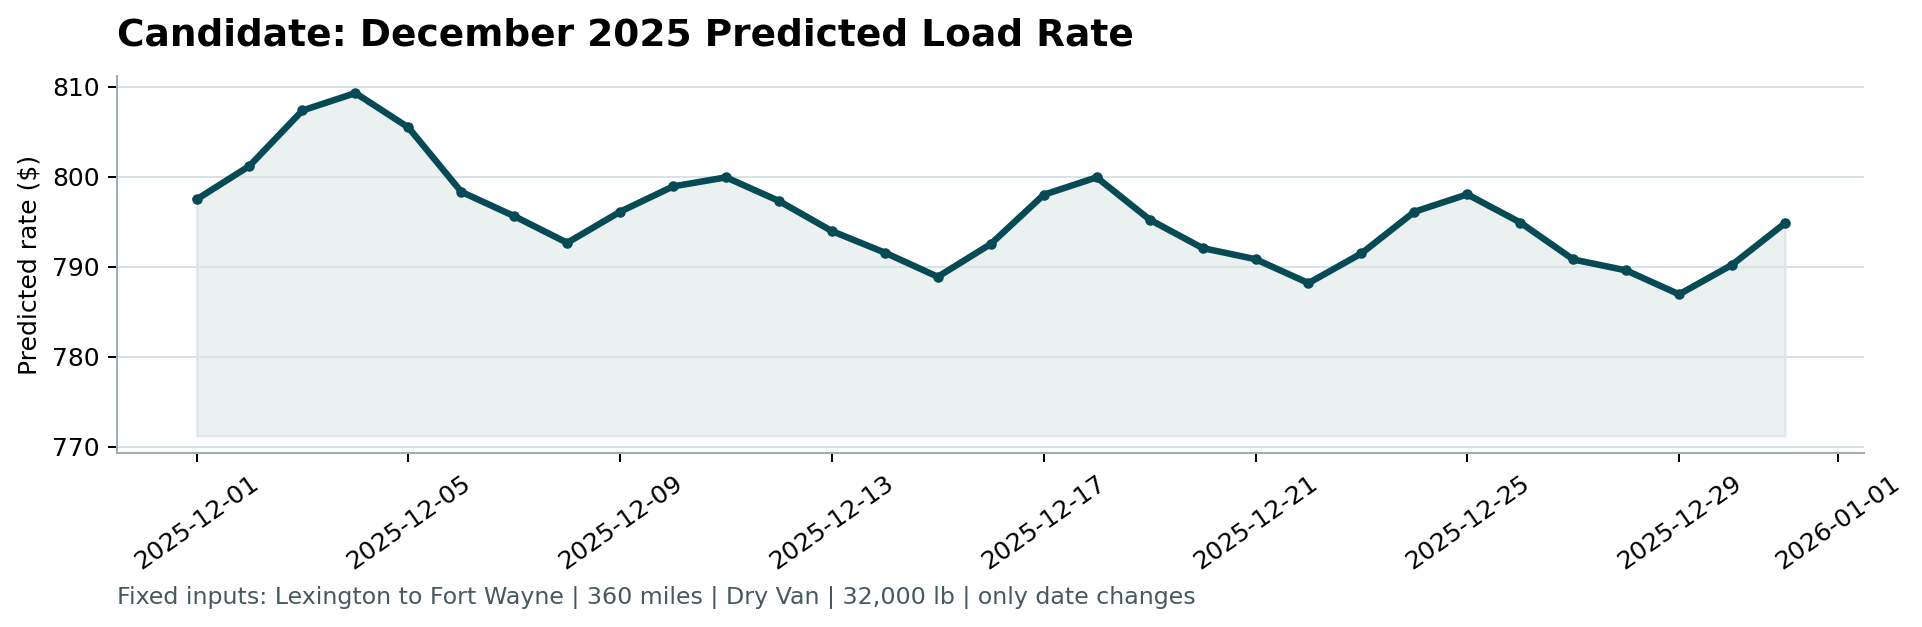


IMPORTANT: Save assessment.ipynb now. The ZIP contains the notebook version saved before this cell finished. Update its notebook copy before submitting.


In [15]:
# Run after the final internal-test comparison has completed.

from pathlib import Path
import sys
import subprocess
import json
import shutil
import importlib.util
from importlib.metadata import version
from datetime import datetime
from xml.sax.saxutils import escape

import numpy as np
import pandas as pd
import joblib
from IPython.display import display, Image as NotebookImage

# ------------------------------------------------------------
# 1. Check that the earlier notebook cells have been run
# ------------------------------------------------------------
needed = [
    "train", "validation", "template", "december",
    "fit_model", "predict_rates", "settings",
    "best_name", "best_core_name",
    "comparison", "final_test_comparison",
    "final_test", "test_predictions"
]

missing = [name for name in needed if name not in globals()]

if missing:
    raise RuntimeError(
        "Run the earlier notebook cells first. Missing: "
        + ", ".join(missing)
    )

ROOT = Path.cwd()
OUTPUT = ROOT / "outputs"
OUTPUT.mkdir(exist_ok=True)

assert (ROOT / "score.py").is_file(), "score.py was not found."

# Install the PDF package only if it is missing.
if importlib.util.find_spec("reportlab") is None:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "reportlab"
    ])

from reportlab.platypus import (
    SimpleDocTemplate, Paragraph, Spacer,
    Table, TableStyle, Image as PDFImage, PageBreak
)
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib import colors
from reportlab.lib.utils import ImageReader

main_kind, main_signals = settings[best_name]
december_kind, december_signals = settings[best_core_name]

assert december_signals is False

# ------------------------------------------------------------
# 2. Train the final main model and predict every validation load
# ------------------------------------------------------------
print("1/7: Training the main model on all labeled data...", flush=True)

final_model = fit_model(train, main_kind, main_signals)

validation_rates = predict_rates(
    final_model, validation, main_signals
)

assert validation["load_id"].is_unique
assert template["load_id"].is_unique
assert set(template["load_id"]) == set(validation["load_id"])

lookup = pd.Series(
    validation_rates,
    index=validation["load_id"]
)

submission = template[["load_id", "predicted_rate"]].copy()
submission["predicted_rate"] = submission["load_id"].map(lookup)

assert len(submission) == 12000
assert np.isfinite(submission["predicted_rate"]).all()
assert submission["predicted_rate"].gt(0).all()

prediction_path = OUTPUT / "validation_predictions.csv"

submission.to_csv(
    prediction_path,
    index=False,
    float_format="%.6f"
)

# ------------------------------------------------------------
# 3. Add training-derived coordinates and predict December
# ------------------------------------------------------------
print("2/7: Preparing the December predictions...", flush=True)

parts = []

for side in ["pickup", "delivery"]:
    part = train[
        [side, f"{side}_lat", f"{side}_lon"]
    ].copy()

    part.columns = ["city", "latitude", "longitude"]
    parts.append(part)

coordinates = (
    pd.concat(parts, ignore_index=True)
    .drop_duplicates()
)

assert not coordinates["city"].duplicated().any(), (
    "A city has conflicting coordinates. Check the source data."
)

coordinates = coordinates.set_index("city")

december_features = december.copy()

for side in ["pickup", "delivery"]:
    december_features[f"{side}_lat"] = (
        december_features[side].map(coordinates["latitude"])
    )
    december_features[f"{side}_lon"] = (
        december_features[side].map(coordinates["longitude"])
    )

coordinate_columns = [
    "pickup_lat", "pickup_lon",
    "delivery_lat", "delivery_lon"
]

assert december_features[coordinate_columns].notna().all().all()

december_model = fit_model(train, december_kind, False)

december_rates = predict_rates(
    december_model, december_features, False
)

december_submission = december[
    [
        "pickup", "delivery", "distance",
        "equipment", "weight", "date", "predicted_rate"
    ]
].copy()

december_submission["predicted_rate"] = december_rates
december_submission["date"] = (
    pd.to_datetime(december_submission["date"])
    .dt.strftime("%Y-%m-%d")
)

assert len(december_submission) == 31
assert np.isfinite(december_rates).all()
assert (december_rates > 0).all()

december_path = OUTPUT / "december_chart_inputs.csv"

december_submission.to_csv(
    december_path,
    index=False,
    float_format="%.6f"
)

# ------------------------------------------------------------
# 4. Run the original assessment scorer
# ------------------------------------------------------------
print("3/7: Running score.py...", flush=True)

scorer_folder = OUTPUT / "scorer_results"

command = [
    sys.executable,
    str(ROOT / "score.py"),
    "--predictions", str(prediction_path),
    "--december-predictions", str(december_path),
    "--output-dir", str(scorer_folder)
]

scorer = subprocess.run(
    command,
    cwd=ROOT,
    capture_output=True,
    text=True
)

print(scorer.stdout)

if scorer.stderr:
    print(scorer.stderr)

scorer.check_returncode()

chart_path = scorer_folder / "candidate_december.png"
assert chart_path.is_file(), "The scorer did not create the chart."

(OUTPUT / "scorer_log.txt").write_text(
    scorer.stdout + "\n" + scorer.stderr,
    encoding="utf-8"
)

# ------------------------------------------------------------
# 5. Save measured results, models, and dependencies
# ------------------------------------------------------------
print("4/7: Saving results and fitted models...", flush=True)

comparison.to_csv(OUTPUT / "model_comparison.csv")
final_test_comparison.to_csv(OUTPUT / "final_test_metrics.csv")

pd.DataFrame({
    "load_id": final_test["load_id"].to_numpy(),
    "date": pd.to_datetime(final_test["date"]).dt.strftime(
        "%Y-%m-%d"
    ).to_numpy(),
    "actual_rate": final_test["posted_rate"].to_numpy(),
    "predicted_rate": test_predictions
}).to_csv(
    OUTPUT / "internal_test_predictions.csv",
    index=False
)

joblib.dump(
    {
        "main_model": final_model,
        "main_model_name": best_name,
        "main_uses_signals": main_signals,
        "december_model": december_model,
        "december_model_name": best_core_name,
        "coordinates": coordinates
    },
    OUTPUT / "models.joblib"
)

packages = [
    "numpy", "pandas", "scikit-learn",
    "scipy", "matplotlib", "joblib", "reportlab"
]

package_versions = {
    package: version(package)
    for package in packages
}

# Preserve any original requirements.txt.
dependency_path = ROOT / "solution-requirements.txt"
dependency_path.write_text(
    "\n".join(
        f"{package}=={package_version}"
        for package, package_version in package_versions.items()
    ) + "\n",
    encoding="utf-8"
)

main_metrics = final_test_comparison.loc[best_name]
baseline_metrics = final_test_comparison.loc["baseline"]

improvement = (
    1 - main_metrics["MAE"] / baseline_metrics["MAE"]
) * 100

summary = {
    "main_model": best_name,
    "december_model": best_core_name,
    "selection_metrics": comparison.to_dict(orient="index"),
    "internal_test_metrics": (
        final_test_comparison.to_dict(orient="index")
    ),
    "mae_improvement_percent": float(improvement),
    "december_min": float(december_rates.min()),
    "december_max": float(december_rates.max()),
    "december_mean": float(december_rates.mean()),
    "package_versions": package_versions
}

(OUTPUT / "metrics.json").write_text(
    json.dumps(summary, indent=2),
    encoding="utf-8"
)

# ------------------------------------------------------------
# 6. Create the PDF report using this notebook's actual results
# ------------------------------------------------------------
print("5/7: Creating the PDF report...", flush=True)

styles = getSampleStyleSheet()
styles["Normal"].fontSize = 10
styles["Normal"].leading = 14
styles["Normal"].spaceAfter = 8

teal = colors.HexColor("#064A56")
styles["Title"].textColor = teal
styles["Heading2"].textColor = teal

story = []

def paragraph(text, style="Normal"):
    story.append(Paragraph(escape(str(text)), styles[style]))

def add_table(rows, widths):
    wrapped_rows = [
        [Paragraph(escape(str(value)), styles["Normal"])
         for value in row]
        for row in rows
    ]

    table = Table(
        wrapped_rows,
        colWidths=widths,
        repeatRows=1,
        hAlign="LEFT"
    )

    table.setStyle(TableStyle([
        ("BACKGROUND", (0, 0), (-1, 0),
         colors.HexColor("#DCECEE")),
        ("VALIGN", (0, 0), (-1, -1), "TOP"),
        ("TOPPADDING", (0, 0), (-1, -1), 6),
        ("BOTTOMPADDING", (0, 0), (-1, -1), 6),
        ("LINEBELOW", (0, 0), (-1, 0), 1, teal),
        ("ROWBACKGROUNDS", (0, 1), (-1, -1),
         [colors.HexColor("#F3F6F7"), colors.white])
    ]))

    story.append(table)
    story.append(Spacer(1, 12))

paragraph("Freight Rate Prediction", "Title")
paragraph("Data review, model comparison, and validation results")

paragraph("1. Data checks", "Heading2")
paragraph(
    f"The task is to predict posted_rate, the total freight price. "
    f"The labeled dataset contains {len(train):,} loads from January "
    f"through October 2025. The final prediction dataset contains "
    f"{len(validation):,} loads from November and December."
)

add_table([
    ["Issue", "Training", "Final prediction data"],
    ["Missing weight",
     train["weight"].isna().sum(),
     validation["weight"].isna().sum()],
    ["Weight at or below zero",
     (train["weight"] <= 0).sum(),
     (validation["weight"] <= 0).sum()],
    ["Missing market_index",
     train["market_index"].isna().sum(),
     validation["market_index"].isna().sum()],
    ["Duplicate rows",
     train.duplicated().sum(),
     validation.duplicated().sum()]
], [250, 100, 150])

paragraph(
    "Zero and negative weights are treated as missing. Missing "
    "numerical inputs are filled with training medians, and extra "
    "flags mark missing values. Cleaning, scaling, and category "
    "encoding are fitted within each training split. load_id is "
    "excluded from prediction features."
)

paragraph(
    f"Training prices range from "
    f"${train['posted_rate'].min():,.2f} to "
    f"${train['posted_rate'].max():,.2f}. Expensive loads are kept "
    f"because the supplied files do not establish whether they "
    f"are errors. Coordinates are used as supplied."
)

paragraph("2. Why the split follows the dates", "Heading2")

add_table([
    ["Purpose", "Training", "Evaluation"],
    ["Choose models",
     "January-June: 28,806",
     "July-August: 9,671"],
    ["Final internal test",
     "January-August: 38,477",
     "September-October: 9,523"],
    ["Final training",
     "January-October: 48,000",
     "Predict 12,000 unlabeled loads"]
], [130, 185, 185])

paragraph(
    "The assessment predicts later months, so the evaluation also "
    "uses later months. Model choice is based on July-August MAE. "
    "September-October is reserved for reporting final internal "
    "performance, without changing the selected models."
)

story.append(PageBreak())

paragraph("3. Models and features", "Heading2")
paragraph(
    "A distance baseline is compared with Ridge regression and "
    "histogram gradient boosting. Each model is tested with core "
    "features and with market_index and quote_signal added. Models "
    "predict dollars per mile, then multiply by distance to obtain "
    "the total load price."
)
paragraph(
    "Core features include city names, equipment, distance, cleaned "
    "weight, four coordinates, weekday, weekend, annual sine and "
    "cosine terms, coordinate differences, and log and inverse "
    "distance. Full models also use the two supplied signals. "
    "Their source is undocumented, so their use assumes they are "
    "available when making a prediction."
)
paragraph(
    "Ridge uses alpha=50. Boosting uses absolute-error loss, "
    "180 iterations, learning rate 0.07, up to 23 leaves, minimum "
    "leaf size 45, L2 regularization 5, and random_state=42. "
    "Distance weights make the boosting loss correspond to "
    "absolute dollar error. The settings are fixed for this "
    "small model comparison."
)

rows = [["Candidate", "July-August MAE", "RMSE"]]
for name, values in comparison.iterrows():
    rows.append([
        name,
        f"${values['MAE']:,.2f}",
        f"${values['RMSE']:,.2f}"
    ])
add_table(rows, [230, 135, 135])

paragraph(
    f"{best_name} is selected for the main predictions because "
    f"it has the lowest selection-period MAE. {best_core_name} "
    f"is selected for the December chart because that input file "
    f"does not provide the two extra signals."
)

paragraph("4. Final internal-test results", "Heading2")

rows = [["Model", "MAE", "RMSE", "Median error", "MAPE"]]
for name, values in final_test_comparison.iterrows():
    rows.append([
        name,
        f"${values['MAE']:,.2f}",
        f"${values['RMSE']:,.2f}",
        f"${values['Median error']:,.2f}",
        f"{values['MAPE (%)']:.2f}%"
    ])
add_table(rows, [140, 85, 85, 105, 85])

paragraph(
    f"The main model has average absolute error of "
    f"${main_metrics['MAE']:,.2f}, compared with "
    f"${baseline_metrics['MAE']:,.2f} for the baseline. "
    f"This is a {improvement:.1f}% improvement. RMSE is "
    f"${main_metrics['RMSE']:,.2f}, which shows that some "
    f"large errors remain. These are internal-test results; "
    f"the final November-December accuracy is unknown."
)

story.append(PageBreak())

paragraph("5. December predictions", "Heading2")
paragraph(
    "The December chart keeps Lexington to Fort Wayne, "
    "360 miles, Dry Van, and 32,000 lb fixed. Only the date "
    "changes. Coordinates are mapped from the labeled dataset. "
    "The core model does not require market_index or quote_signal."
)

image_width, image_height = ImageReader(
    str(chart_path)
).getSize()

story.append(PDFImage(
    str(chart_path),
    width=500,
    height=500 * image_height / image_width
))
story.append(Spacer(1, 10))

paragraph(
    f"December predictions range from ${december_rates.min():,.2f} "
    f"to ${december_rates.max():,.2f}. Changes come from calendar "
    f"features. Since training contains no November or December "
    f"examples, the seasonal pattern is uncertain."
)

paragraph("6. Output checks and limitations", "Heading2")
paragraph(
    "The original score.py completed successfully. It validates "
    "12,000 load predictions and 31 fixed December predictions, "
    "then creates candidate_december.png. This validates the "
    "file format, not final prediction accuracy."
)
paragraph(
    "Main limitations are expensive outliers, unfamiliar cities, "
    "future seasonal behavior, and undocumented signal origins. "
    "Further work could test more historical time windows and "
    "investigate the largest errors. No unseen-city stress-test "
    "result is claimed here because this notebook has not run "
    "that experiment."
)
paragraph(
    "Source files: train-test.csv, validation.csv, "
    "validation-predictions-template.csv, december-chart-inputs.csv, "
    "freight-rate-ml-assessment.pdf, and the supplied score.py."
)

def footer(canvas, document):
    canvas.setFont("Helvetica", 8)
    canvas.drawString(48, 25, "Freight Rate Prediction")
    canvas.drawRightString(548, 25, str(document.page))

report_path = OUTPUT / "freight_rate_report.pdf"

SimpleDocTemplate(
    str(report_path),
    pagesize=(595.28, 841.89),
    leftMargin=48,
    rightMargin=47,
    topMargin=40,
    bottomMargin=45
).build(
    story,
    onFirstPage=footer,
    onLaterPages=footer
)

# ------------------------------------------------------------
# 7. Write a README and make a submission package
# ------------------------------------------------------------
print("6/7: Writing README and packaging files...", flush=True)

readme_path = ROOT / "README.md"

if readme_path.exists():
    backup_name = (
        "README-backup-"
        + datetime.now().strftime("%Y%m%d-%H%M%S-%f")
        + ".md"
    )
    shutil.copy2(readme_path, ROOT / backup_name)

readme = f"""# Freight Rate Prediction

This project predicts freight prices using the supplied load data.

## Approach

Models are trained on January-June and compared on July-August.
The selected models are then tested on September-October after
training on January-August. Final models use all 48,000 labeled loads.

The main model is `{best_name}`. The December chart uses
`{best_core_name}` because its inputs lack market_index and quote_signal.

Non-positive weights become missing. Missing numerical inputs are
filled using training medians. Scaling and categorical encoding are
fitted only on training data. Unknown city names are handled by the
encoder. Expensive loads are retained.

## Internal-test results

Main model MAE: ${main_metrics['MAE']:,.2f}
Main model RMSE: ${main_metrics['RMSE']:,.2f}
Main model median absolute error: ${main_metrics['Median error']:,.2f}
Main model MAPE: {main_metrics['MAPE (%)']:.2f}%
Baseline MAE: ${baseline_metrics['MAE']:,.2f}

The main model improves MAE by {improvement:.1f}% over the baseline.
Final November-December accuracy is unknown because labels are absent.

## Run

1. Install the packages:

   python -m pip install -r solution-requirements.txt

2. Open assessment.ipynb in Jupyter.
3. Restart the kernel and run all cells in order.
4. The notebook creates predictions, runs score.py, and builds the report.

To run the scorer separately:

python score.py --predictions outputs/validation_predictions.csv --december-predictions outputs/december_chart_inputs.csv --output-dir outputs/scorer_results

The supplied scorer checks output format and creates the chart.
Spotter calculates final prediction accuracy.

## Outputs

- outputs/validation_predictions.csv
- outputs/december_chart_inputs.csv
- outputs/scorer_results/candidate_december.png
- outputs/freight_rate_report.pdf
- outputs/model_comparison.csv
- outputs/final_test_metrics.csv
- outputs/internal_test_predictions.csv
- outputs/metrics.json
- outputs/models.joblib

The original input CSVs remain unchanged in data/.

## Limitations

Large price outliers still cause substantial errors. Unfamiliar cities
and future seasonality are additional concerns. The two extra signals
are supplied but their origins are undocumented.

## Submission

Publish an accessible GitHub repository containing the notebook,
dependencies, and run instructions. Submit the prediction file and
report, and record a 2-3 minute Loom explaining the solution.
Follow the assessment rules about assistance and describe your
contribution accurately.
"""

readme_path.write_text(readme, encoding="utf-8")

# The package is regenerated on each run.
package_folder = ROOT / "submission_package"

if package_folder.exists():
    shutil.rmtree(package_folder)

package_folder.mkdir()

for path in [
    ROOT / "score.py",
    ROOT / "README.md",
    dependency_path
]:
    shutil.copy2(path, package_folder / path.name)

if (ROOT / "requirements.txt").is_file():
    shutil.copy2(
        ROOT / "requirements.txt",
        package_folder / "requirements.txt"
    )

shutil.copytree(ROOT / "data", package_folder / "data")
shutil.copytree(OUTPUT, package_folder / "outputs")

# Copy the most recently saved notebook.
notebook_path = ROOT / "assessment.ipynb"

if notebook_path.is_file():
    shutil.copy2(
        notebook_path,
        package_folder / "assessment.ipynb"
    )

zip_path = shutil.make_archive(
    str(ROOT / "freight_submission"),
    "zip",
    root_dir=ROOT,
    base_dir="submission_package"
)

print("7/7: Finished.")
print("\nMain predictions:", prediction_path)
print("December predictions:", december_path)
print("Report:", report_path)
print("README:", readme_path)
print("ZIP package:", zip_path)

display(submission.head())
display(december_submission.head())
display(NotebookImage(filename=str(chart_path)))

print(
    "\nIMPORTANT: Save assessment.ipynb now. The ZIP contains the "
    "notebook version saved before this cell finished. Update its "
    "notebook copy before submitting."
)

In [16]:
shutil.copy2(
    ROOT / "assessment.ipynb",
    ROOT / "submission_package" / "assessment.ipynb"
)

shutil.make_archive(
    str(ROOT / "freight_submission"),
    "zip",
    root_dir=ROOT,
    base_dir="submission_package"
)

print("ZIP updated with the saved notebook.")

ZIP updated with the saved notebook.


In [17]:
from pathlib import Path
import textwrap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

OUTPUT = Path("outputs")
OUTPUT.mkdir(exist_ok=True)

required = [
    "train", "validation", "comparison",
    "final_test_comparison", "final_test",
    "test_predictions", "best_name", "best_core_name"
]

missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(
        "Run the earlier notebook cells first: " + ", ".join(missing)
    )

december_file = OUTPUT / "december_chart_inputs.csv"
if not december_file.is_file():
    raise FileNotFoundError(
        "Generate outputs/december_chart_inputs.csv first."
    )

december_report = pd.read_csv(december_file)
december_report["date"] = pd.to_datetime(december_report["date"])

report_path = OUTPUT / "freight_rate_report_classic.pdf"


def new_page(title, page_number):
    fig = plt.figure(figsize=(8.27, 11.69), facecolor="white")

    fig.text(
        0.08, 0.945, title,
        fontsize=17, fontweight="bold", va="top"
    )

    fig.add_artist(plt.Line2D(
        [0.08, 0.92], [0.91, 0.91],
        transform=fig.transFigure,
        color="black", linewidth=0.8
    ))

    fig.text(
        0.08, 0.035,
        "Freight Rate Prediction Assessment",
        fontsize=8
    )

    fig.text(
        0.92, 0.035, str(page_number),
        fontsize=8, ha="right"
    )

    return fig


def paragraph(fig, text, top, width=90, size=10):
    wrapped = textwrap.fill(text, width=width)
    fig.text(
        0.08, top, wrapped,
        fontsize=size, va="top", linespacing=1.5
    )


def simple_table(fig, rows, headings, position, widths=None):
    ax = fig.add_axes(position)
    ax.axis("off")

    table = ax.table(
        cellText=rows,
        colLabels=headings,
        colWidths=widths,
        cellLoc="left",
        colLoc="left",
        bbox=[0, 0, 1, 1]
    )

    table.auto_set_font_size(False)
    table.set_fontsize(9)

    for (row, column), cell in table.get_celld().items():
        cell.set_edgecolor("black")
        cell.set_linewidth(0.5)
        cell.set_facecolor("white")
        if row == 0:
            cell.set_text_props(weight="bold")
            cell.set_facecolor("#eeeeee")

    return table


with plt.style.context("classic"), plt.rc_context({
    "font.family": "serif",
    "font.size": 10,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "black",
    "axes.labelcolor": "black",
    "text.color": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "pdf.fonttype": 42
}):
    with PdfPages(report_path) as pdf:

        # ====================================================
        # PAGE 1: DATA AND VALIDATION
        # ====================================================
        fig = new_page("Freight Rate Prediction", 1)

        paragraph(
            fig,
            "The objective is to predict the total freight price "
            "(posted_rate). The labeled data contains 48,000 loads "
            "from January to October 2025. Predictions are required "
            "for 12,000 loads from November and December.",
            top=0.885
        )

        fig.text(
            0.08, 0.79, "Data-quality checks",
            fontsize=12, fontweight="bold"
        )

        quality_rows = [
            [
                "Missing weight",
                str(train["weight"].isna().sum()),
                str(validation["weight"].isna().sum())
            ],
            [
                "Weight at or below zero",
                str((train["weight"] <= 0).sum()),
                str((validation["weight"] <= 0).sum())
            ],
            [
                "Missing market_index",
                str(train["market_index"].isna().sum()),
                str(validation["market_index"].isna().sum())
            ],
            [
                "Duplicate rows",
                str(train.duplicated().sum()),
                str(validation.duplicated().sum())
            ]
        ]

        simple_table(
            fig,
            quality_rows,
            ["Check", "Training", "Prediction data"],
            [0.08, 0.61, 0.84, 0.16],
            widths=[0.50, 0.22, 0.28]
        )

        paragraph(
            fig,
            "Zero and negative weights are treated as missing. "
            "Numerical values are filled using training medians. "
            "Cleaning, scaling, and category encoding are fitted "
            "only on the training portion. Expensive loads are "
            "retained because their validity is not established.",
            top=0.585
        )

        fig.text(
            0.08, 0.475, "Time-based validation",
            fontsize=12, fontweight="bold"
        )

        simple_table(
            fig,
            [
                ["Model selection", "Jan-Jun: 28,806", "Jul-Aug: 9,671"],
                ["Final internal test", "Jan-Aug: 38,477", "Sep-Oct: 9,523"],
                ["Final training", "Jan-Oct: 48,000", "Nov-Dec: 12,000"]
            ],
            ["Stage", "Training", "Evaluation / prediction"],
            [0.08, 0.315, 0.84, 0.14],
            widths=[0.30, 0.32, 0.38]
        )

        paragraph(
            fig,
            "The split follows the dates because the assessment "
            "requires predictions for later months. July-August "
            "results determine the model choice. September-October "
            "is kept for the final internal evaluation.",
            top=0.285
        )

        paragraph(
            fig,
            "Features describe the route, equipment, weight, and "
            "calendar. Full models also use market_index and "
            "quote_signal. Their origins are undocumented. Models "
            "estimate dollars per mile, then multiply by distance "
            "to obtain the total price.",
            top=0.175
        )

        pdf.savefig(fig)
        plt.close(fig)

        # ====================================================
        # PAGE 2: MODEL RESULTS
        # ====================================================
        fig = new_page("Model Comparison and Test Results", 2)

        paragraph(
            fig,
            "A distance baseline, Ridge regression, and histogram "
            "gradient boosting were compared. MAE measures average "
            "absolute dollar error. Lower values are better.",
            top=0.885
        )

        selection_rows = [
            [
                name,
                f"${row['MAE']:,.2f}",
                f"${row['RMSE']:,.2f}"
            ]
            for name, row in comparison.iterrows()
        ]

        simple_table(
            fig,
            selection_rows,
            ["Model", "Jul-Aug MAE", "Jul-Aug RMSE"],
            [0.08, 0.60, 0.84, 0.20],
            widths=[0.44, 0.28, 0.28]
        )

        paragraph(
            fig,
            f"The main model is {best_name}, selected using "
            f"July-August MAE. The December model is "
            f"{best_core_name}, selected among models that do not "
            f"require the two additional signals. The choices "
            f"remain unchanged after the final test.",
            top=0.575
        )

        test_rows = [
            [
                name,
                f"${row['MAE']:,.2f}",
                f"${row['RMSE']:,.2f}",
                f"{row['MAPE (%)']:.2f}%"
            ]
            for name, row in final_test_comparison.iterrows()
        ]

        fig.text(
            0.08, 0.47, "September-October internal test",
            fontsize=12, fontweight="bold"
        )

        simple_table(
            fig,
            test_rows,
            ["Model", "MAE", "RMSE", "MAPE"],
            [0.08, 0.315, 0.84, 0.135],
            widths=[0.34, 0.22, 0.22, 0.22]
        )

        ax = fig.add_axes([0.14, 0.115, 0.76, 0.155])

        test_mae = final_test_comparison["MAE"]
        bars = ax.bar(
            test_mae.index,
            test_mae.values,
            color="white",
            edgecolor="black",
            hatch="//"
        )

        ax.set_ylabel("MAE ($)")
        ax.set_ylim(0, test_mae.max() * 1.25)
        ax.grid(axis="y", linestyle=":", alpha=0.5)
        ax.set_axisbelow(True)

        for bar, value in zip(bars, test_mae.values):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                value + test_mae.max() * 0.035,
                f"{value:.2f}",
                ha="center", fontsize=9
            )

        pdf.savefig(fig)
        plt.close(fig)

        # ====================================================
        # PAGE 3: DECEMBER AND LIMITATIONS
        # ====================================================
        fig = new_page("December Predictions and Limitations", 3)

        paragraph(
            fig,
            "The fixed load is Lexington to Fort Wayne, 360 miles, "
            "Dry Van, and 32,000 lb. Only the date changes. "
            "Coordinates come from the labeled data, and the core "
            "model does not require market_index or quote_signal.",
            top=0.885
        )

        # Include the chart produced by the original scorer.
        scorer_chart = OUTPUT / "scorer_results" / "candidate_december.png"

        if scorer_chart.is_file():
            ax = fig.add_axes([0.06, 0.47, 0.88, 0.32])
            ax.imshow(plt.imread(scorer_chart))
            ax.axis("off")
        else:
            raise FileNotFoundError(
                "Run score.py first to create candidate_december.png."
            )

        rates = december_report["predicted_rate"]

        paragraph(
            fig,
            f"Predictions range from ${rates.min():,.2f} to "
            f"${rates.max():,.2f}, averaging ${rates.mean():,.2f}. "
            f"The calendar features produce the date-dependent "
            f"changes. No November or December examples are "
            f"available for training, so seasonality is uncertain.",
            top=0.43
        )

        fig.text(
            0.08, 0.325, "Limitations",
            fontsize=12, fontweight="bold"
        )

        paragraph(
            fig,
            "Large price outliers still cause substantial errors. "
            "Unfamiliar cities and changes in future market conditions "
            "may also affect performance. Further work could test "
            "more time windows, investigate large errors, and "
            "confirm how the supplied signals are produced.",
            top=0.30
        )

        paragraph(
            fig,
            "The scorer checks file format and generates the chart. "
            "Final prediction accuracy is calculated by Spotter. "
            "The reported metrics are from the internal "
            "September-October test.",
            top=0.19
        )

        paragraph(
            fig,
            "Sources: supplied assessment PDF, training and validation "
            "CSVs, prediction template, December inputs, and score.py.",
            top=0.105,
            size=8
        )

        pdf.savefig(fig)
        plt.close(fig)

print("Report saved:", report_path.resolve())

Report saved: C:\Users\abc\freight-assessment\outputs\freight_rate_report_classic.pdf
